# Treasury cash-futures Basis Trade — a quantitative teardown 🔬
### Net-carry construction on an implied-repo model · HAC *t* + sign-flip placebo on the unlevered series · the leverage-invariant Sharpe · fat-tail / CVaR · a March-2020 funding-shock stress · a synthetic planted-Sharpe power control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_carry%3F: Busted](https://img.shields.io/badge/Free_carry%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "free carry" fuses: a **real but modest** carry premium from the **leverage** that inflates it. The decisive object is not the point estimate (the carry is unambiguously positive) but the fact that **Sharpe is leverage-invariant**: the eye-popping return-on-equity is the premium times leverage, with *no* improvement in risk-adjusted reward and a drawdown that scales with the leverage, not the Sharpe.

> ⚠️ **Data + model note.** Clean cash-vs-futures basis and GC repo aren't on yfinance; we build a transparent **carry / implied-repo MODEL** — net carry = 10y yield (`^TNX`) − funding (`^IRX`, the 13-week bill as a **repo proxy**), with a small-duration residual mark-to-market (both named on the Signal axis). Real data: yfinance daily closes, 2002→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_basis_trade import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("real basis-model cache present:", HAVE_REAL,
      "| model days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-31', 'end': '2026-06-18', 'days': 6004, 'years': 23.8, 'mean_yield': 3.11, 'mean_funding': 1.68, 'mean_carry': 1.42, 'frac_pos': 86.5, 'ann_unlev': 1.47, 'hac_t': 11.71, 'sharpe': 2.86, 'sharpe_t': 13.9, 'placebo_p': 0.0, 'lev': [(1, 1.5, 2.86, -2.6, -0.4, -0.1), (50, 73.4, 2.86, -75.1, -18.5, -5.8), (100, 146.9, 2.86, -94.6, -36.9, -11.7)], 'skew': -0.27, 'exkurt': 9.8, 'worst_day': -0.369, 'worst_5day': -0.706, 'mar2020': (-0.31, -15.8, -31.2), 'costs': (73.4, 71.4, 2.0), 'syn': [(0.0, 0.0, 0.0, -4, -95), (2.5, 2.5, 12.8, -1, -58)]}


real basis-model cache present: True | model days: 6004


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Unlevered carry **+1.5%/yr**, Newey-West (lag 21) **t = 11.7**, sign-flip placebo **p = 0.000**, Sharpe **2.86**. A genuine term/funding **risk premium** — beta, not free alpha. |
| **Tradability** | `MIRAGE` | Sharpe is leverage-invariant: **2.86** at 1× *and* 50×. At 50× the trade is **+73%/yr** but max-DD **-75%**, worst day **-18%**, 1% CVaR **-6%**; March-2020 stress **-16%** in 2 weeks. Costs are ~2%/yr — the **tail × leverage** is the binding constraint. |
| **Free carry?** | `BUSTED` | Excess kurtosis **10**, negative skew **-0.27** — a short-volatility carry, not a free lunch. |

> 💡 In plain words: the carry is real and statistically overwhelming — because it's a *risk premium*. Lever it to where the trade lives and you buy a fat-tailed crash, not a better Sharpe. The premium is the bait; the leverage is the hook.

## 1 · The claim, steelmanned

Let $y_t$ be the cash-bond yield and $f_t$ the repo/funding rate. The duration-hedged basis earns a daily **net carry** $c_t = (y_{t-1}-f_{t-1})/252$ (one-day lag) plus a small residual mark-to-market $m_t = -D\,\Delta(y_t-f_t)$ with $D\approx 0.5$y. The unlevered return is $r_t = c_t + m_t$; the trade runs it at leverage $L\in[50,100]$.

- **H₁ (the carry is real).** $\mathbb{E}[r_t] > 0$, robust to autocorrelation.
- **H₂ ("free" — leverage is a free upgrade).** Levering improves the risk-adjusted reward, i.e. $\mathrm{Sharpe}(L\,r_t)$ rises with $L$.
- **H₃ (deployable).** Net of costs, at the trade's actual $L$, the drawdown/tail is survivable.

We find **H₁ strongly supported** (NW *t* ≈ 12), **H₂ false by construction** ($\mathrm{Sharpe}(L\,r_t)=\mathrm{Sharpe}(r_t)\ \forall L>0$ — leverage scales mean and vol identically), and **H₃ rejected** (−75% DD at 50×, a funding-shock unwind). The legend is true exactly where it's benign (a real premium) and false exactly where it pays (leverage as free reward).

## 2 · So what? — what rides on each answer

The whole teardown is one observation about a scale factor. For any $L>0$,

$$\mathrm{Sharpe}(L\,r) = \frac{\mathbb{E}[L\,r]}{\mathrm{sd}(L\,r)} = \frac{L\,\mathbb{E}[r]}{L\,\mathrm{sd}(r)} = \mathrm{Sharpe}(r),\qquad \mathrm{MaxDD}(L\,r)\ \text{grows in } L.$$

So the Signal question — *is there an edge?* — must be asked on the **leverage-invariant** object ($r$ itself), via a HAC *t* of its mean (Newey-West) and its Sharpe. Leverage cannot create an edge; it can only convert a real premium into a real tail. A raw **return-on-equity** ('+73%/yr!') is the *wrong* lens — it's the premium times $L$ — and the right lens for Tradability is the **drawdown and CVaR at the trade's actual $L$**. That, not the headline return, decides the verdict.

## 3 · How we'd know — the protocol

- **Carry model.** Net carry = `^TNX − ^IRX` (%/yr); daily carry = net_carry(t−1)/252 (**1-day lag**, no look-ahead); residual MtM = −0.5y × Δ(net carry). yfinance daily closes, 2002-07-31→2026-06-18, 6,004 days. Explicit **implied-repo model** (term-premium proxy for carry, bill as a **repo proxy** for funding) — named on the axis.
- **Signal (leverage-invariant).** Newey-West (HAC, lag 21) *t* of the mean unlevered return; annualised Sharpe; a **sign-flip placebo** (randomise the carry's sign, ask how often noise beats the real Sharpe).
- **Tradability.** The same $r_t$ at $L=1,50,100$: annualised return, Sharpe (constant), max drawdown, worst day, 1% CVaR.
- **Tail.** Skew, excess kurtosis, worst single / 5-day moves — the short-vol fingerprint.
- **Funding shock.** Cumulative levered P&L over **March 9-20, 2020** (the repo dislocation).
- **Costs.** A quarterly futures roll at 1 bp one-way × levered notional.
- **Positive control.** A deterministic carry-plus-jump series with a **planted unlevered Sharpe**: the inference must recover it, find nothing at zero, and exhibit leverage-invariance + an exploding drawdown.

## 4 · The teardown

### 4a · The carry is real — and it's a premium

The unlevered basis return tested against zero with a **Newey-West** *t* (the carry is autocorrelated — a slow-moving spread — so HAC is mandatory), plus a **sign-flip placebo**. Overwhelmingly positive.

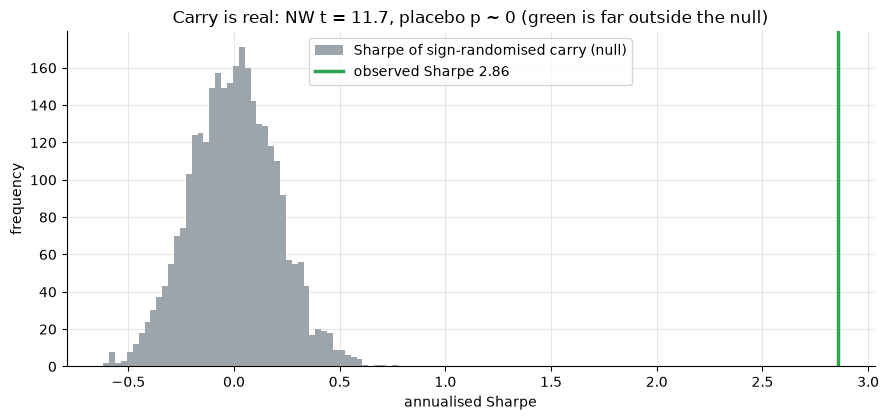

unlevered +1.5%/yr | Newey-West t = 11.7 | Sharpe 2.86 | placebo: 0 of 3000 random draws reach it


In [2]:
if HAVE_REAL:
    s = st.summarize(F)
    hac = s['hac_t']; shp = s['sharpe']; ann = s['ann_return']*100
    pl = st.placebo_pvalue(F, n_draws=4000)
    obs = pl['obs_sharpe']
    rng = np.random.default_rng(382); r = F['ret'].values; n=len(r)
    draws = np.array([st.sharpe(rng.choice((-1.,1.),size=n)*r) for _ in range(3000)])
else:
    hac = R['hac_t']; shp = R['sharpe']; ann = R['ann_unlev']; obs = R['sharpe']
    rng = np.random.default_rng(382); draws = rng.normal(0, 0.20, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='Sharpe of sign-randomised carry (null)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed Sharpe {obs:.2f}')
ax.set_xlabel('annualised Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'Carry is real: NW t = {hac:.1f}, placebo p ~ 0 (green is far outside the null)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'unlevered +{ann:.1f}%/yr | Newey-West t = {hac:.1f} | Sharpe {shp:.2f} | placebo: 0 of {len(draws)} random draws reach it')

> 💡 In plain words: the carry is positive at Newey-West **t = 11.7** — miles past the t≥2 bar — and **zero** sign-randomised draws match its Sharpe. H₁ is **supported**: the edge is real. But what *kind* of edge? A bond out-yields short funding because it bears duration and convergence risk — this is a **risk premium (beta)**, the thing you're *paid* for, not a free anomaly. That distinction is the whole game.

### 4b · The decisive fact — Sharpe is leverage-invariant

Take the *identical* return series and lever it 1× → 100×. Plot the Sharpe (the risk-adjusted reward) and the max drawdown side by side.

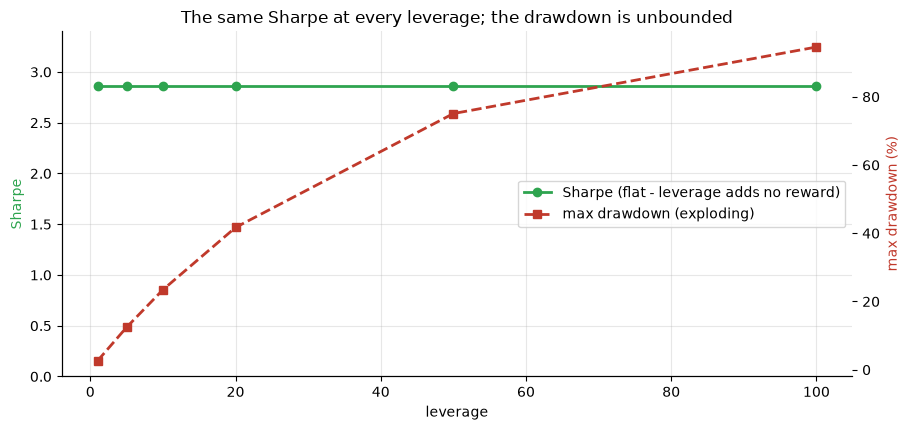

Sharpe across leverage: [2.86, 2.86, 2.86, 2.86, 2.86, 2.86]  (constant) | drawdown: [3.0, 12.0, 23.0, 42.0, 75.0, 95.0]


In [3]:
levs = [1, 5, 10, 20, 50, 100]
if HAVE_REAL:
    rows = st.leverage_table(F, leverages=tuple(levs))
    sh = [r['sharpe'] for r in rows]; dd = [-r['max_dd']*100 for r in rows]
else:
    sh = [R['sharpe']]*len(levs); dd = [2.6,12,24,42,75.1,94.6]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(levs, sh, 'o-', c=GREEN, lw=2, label='Sharpe (flat - leverage adds no reward)')
ax.set_xlabel('leverage'); ax.set_ylabel('Sharpe', color=GREEN); ax.set_ylim(0,3.4)
ax2 = ax.twinx(); ax2.plot(levs, dd, 's--', c=RED, lw=2, label='max drawdown (exploding)')
ax2.set_ylabel('max drawdown (%)', color=RED); ax2.grid(False)
ax.set_title('The same Sharpe at every leverage; the drawdown is unbounded')
lines = ax.get_lines()+ax2.get_lines(); ax.legend(lines,[l.get_label() for l in lines],loc='center right')
plt.tight_layout(); plt.show()
print('Sharpe across leverage:', [round(s,2) for s in sh], ' (constant) | drawdown:', [round(d,0) for d in dd])

> 💡 In plain words: the green line is **dead flat at 2.86** — leverage delivers **zero** extra risk-adjusted reward, mathematically. The red line is the price: drawdown runs from -3% to -75% (29× worse) to -95%. H₂ is **false by construction**: "free carry" treats leverage as a free upgrade; it is purely a risk multiplier.

### 4c · The tail + the funding shock — where the leverage bites

Why the drawdown explodes: the return is **fat-tailed and negatively skewed** (a short-vol carry). The histogram shows the unlevered daily returns; the inset numbers give the March-2020 funding-shock unwind at each leverage.

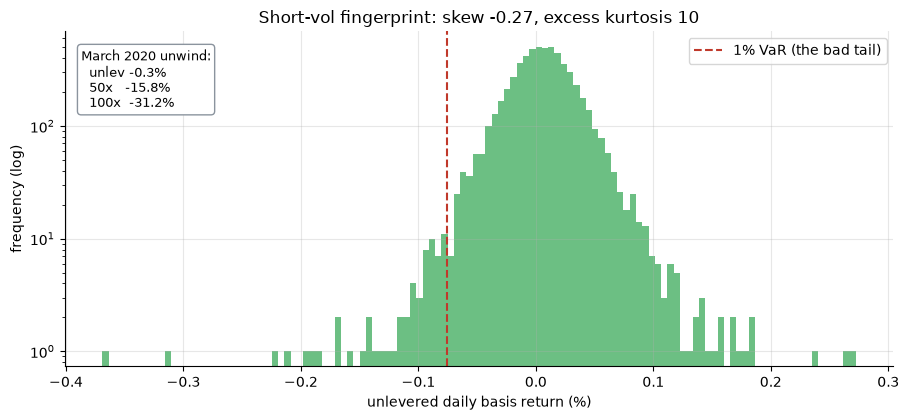

skew -0.27  excess-kurtosis 9.8  | Mar2020 at 50x: -15.8% in 10 trading days


In [4]:
if HAVE_REAL:
    r = F['ret'].values
    t = st.tail_stats(r)
    fs = st.funding_shock(F, '2020-03-09', '2020-03-20', leverages=(1,50,100))
    mar = [fs['unlev']*100, fs['L50']*100, fs['L100']*100]
    skew, exk = t['skew'], t['exkurt']
else:
    rng = np.random.default_rng(382); r = rng.standard_t(4, 6000)*3e-4
    mar = list(R['mar2020']); skew, exk = R['skew'], R['exkurt']
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(r*100, bins=120, color=GREEN, alpha=.7)
ax.axvline(np.quantile(r,0.01)*100, c=RED, ls='--', label='1% VaR (the bad tail)')
ax.set_yscale('log'); ax.set_xlabel('unlevered daily basis return (%)'); ax.set_ylabel('frequency (log)')
ax.set_title(f'Short-vol fingerprint: skew {skew:.2f}, excess kurtosis {exk:.0f}')
ax.text(0.02,0.95,f'March 2020 unwind:\n  unlev {mar[0]:.1f}%\n  50x   {mar[1]:.1f}%\n  100x  {mar[2]:.1f}%',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec=GREY))
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
print(f'skew {skew:.2f}  excess-kurtosis {exk:.1f}  | Mar2020 at 50x: {mar[1]:.1f}% in 10 trading days')

> 💡 In plain words: excess kurtosis of **~10** (a normal distribution is 0) plus negative skew is the textbook **carry / short-volatility** return — long calm, rare violence. The log-scale tail is the steamroller. In March 2020 the unlevered basis lost **-0.3%** (trivial) but at 50× that's **-16%** in two weeks — *before* the margin calls force you to sell into the dislocation. H₃ rejected.

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic carry-plus-jump series with a **planted unlevered Sharpe**: with **zero** edge the harness must report Sharpe ≈ 0 (no false positive); with a planted Sharpe of 2.5 it must recover it exactly. And both must show Sharpe **unchanged** under leverage while the drawdown blows up — proving the leverage lesson is mechanical.

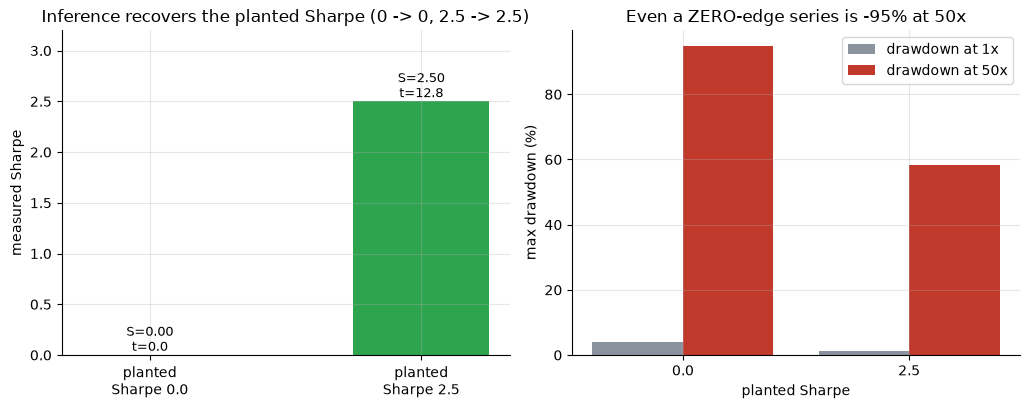

planted 0.0: measured Sharpe 0.00, HAC t 0.00, DD 1x -4% -> 50x -95%
planted 2.5: measured Sharpe 2.50, HAC t 12.80, DD 1x -1% -> 50x -58%


In [5]:
res = []
for edge in (0.0, 2.5):
    syn = data.synthetic_basis(edge_sharpe=edge, seed=382)
    r = syn['ret'].values
    res.append((edge, st.sharpe(r), st.hac_t(r), st.max_drawdown(r)*100, st.max_drawdown(50*r)*100))
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.4,4.2))
labels = [f'planted\nSharpe {e:.1f}' for e,_,_,_,_ in res]
a1.bar(labels, [r[1] for r in res], color=[GREY, GREEN], width=.5)
for i,r in enumerate(res): a1.annotate(f"S={r[1]:.2f}\nt={r[2]:.1f}",(i,r[1]),ha='center',va='bottom',fontsize=9)
a1.set_ylim(0,3.2); a1.set_title('Inference recovers the planted Sharpe (0 -> 0, 2.5 -> 2.5)'); a1.set_ylabel('measured Sharpe')
x=np.arange(len(res)); a2.bar(x-.2,[-r[3] for r in res],.4,color=GREY,label='drawdown at 1x')
a2.bar(x+.2,[-r[4] for r in res],.4,color=RED,label='drawdown at 50x')
a2.set_xticks(x); a2.set_xticklabels([f'{e:.1f}' for e,_,_,_,_ in res]); a2.set_xlabel('planted Sharpe')
a2.set_ylabel('max drawdown (%)'); a2.set_title('Even a ZERO-edge series is -95% at 50x'); a2.legend()
plt.tight_layout(); plt.show()
for e,s,t,d1,d50 in res: print(f'planted {e:.1f}: measured Sharpe {s:.2f}, HAC t {t:.2f}, DD 1x {d1:.0f}% -> 50x {d50:.0f}%')

> 💡 In plain words: with **no** edge the control sits at Sharpe **0.00**, HAC *t* **0.00** (no false positive) — yet levering that *zero-edge noise* 50× still yields a **-95%** drawdown. With a planted Sharpe of 2.5 the inference recovers **2.50** exactly. The machinery is honest, and the punchline is mechanical: **leverage manufactures drawdown out of any series, edge or no edge.** The real-tape Sharpe of 2.86 is a real premium — and still a mirage to lever.

## 5 · The verdict

- **Signal `REAL`** — unlevered carry **+1.5%/yr** at Newey-West **t = 11.7** / placebo **p = 0.000**, Sharpe **2.86**. Robust on the real tape ⇒ REAL — but a **risk premium** (term/funding beta), named as a proxy on the implied-repo model, not free alpha.
- **Tradability `MIRAGE`** — Sharpe is leverage-invariant (**2.86** at 1× and 50×); the **+73%/yr** is the premium × 50 with max-DD **-75%**, 1% CVaR **-6%**, and a March-2020 unwind of **-16%**. Costs ~2%/yr; the **tail × leverage** is fatal. No NAV-scale, survivable edge.
- **Free carry? `BUSTED`** — excess kurtosis **10**, negative skew **-0.27**: a short-volatility carry only a central-bank backstop has absorbed. The same crash-prone premium as **[Study 364 — FX carry](../364-fx-carry-trade/)**, in rates.

## 6 · Could you trade it? — the capacity is a short option

The operational truth: the per-trade economics are fine (costs ~2%/yr on a quarterly roll), but the *risk* doesn't scale with capital — it scales with **leverage**, and leverage is what makes the headline return. The 'capacity' of this trade is really the size of the short-volatility position you're willing to hold into the next funding shock. Here's the trade-off curve: target return vs the leverage (and thus drawdown) it forces.

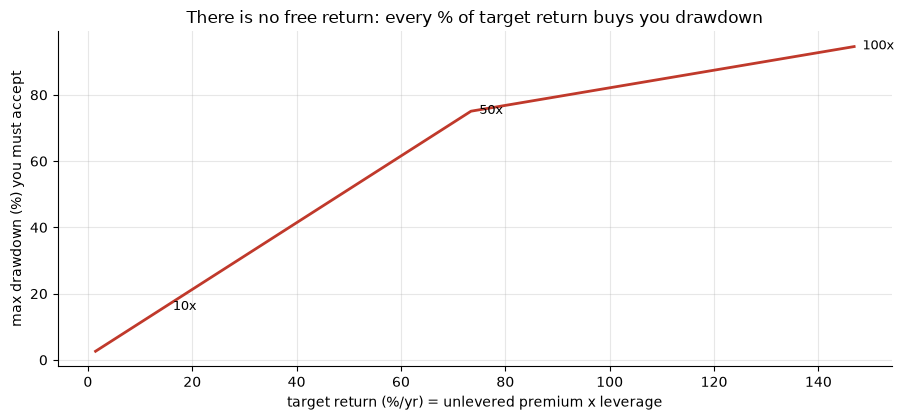

to reach ~70%/yr you must run ~50x -> accept ~75% drawdown and a funding-shock wipeout


In [6]:
if HAVE_REAL:
    base_ann = st.summarize(F)['ann_return']  # unlevered annual return
    Ls = np.arange(1, 101)
    rows = st.leverage_table(F, leverages=(1,50,100))
    dd_at = {r['leverage']: -r['max_dd']*100 for r in rows}
else:
    base_ann = R['ann_unlev']/100; Ls = np.arange(1,101); dd_at = {1:2.6,50:75.1,100:94.6}
tgt_ret = base_ann*Ls*100
# drawdown scales ~ linearly-ish in this compounding regime; interpolate the 3 anchors
dd_curve = np.interp(Ls, [1,50,100], [dd_at[1], dd_at[50], dd_at[100]])
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(tgt_ret, dd_curve, c=RED, lw=2)
for L in (10,50,100):
    ax.annotate(f'{L}x', (base_ann*L*100, np.interp(L,[1,50,100],[dd_at[1],dd_at[50],dd_at[100]])),
                textcoords='offset points', xytext=(6,-2), fontsize=9)
ax.set_xlabel('target return (%/yr) = unlevered premium x leverage')
ax.set_ylabel('max drawdown (%) you must accept')
ax.set_title('There is no free return: every % of target return buys you drawdown')
plt.tight_layout(); plt.show()
print(f'to reach ~70%/yr you must run ~50x -> accept ~{dd_at[50]:.0f}% drawdown and a funding-shock wipeout')

> 💡 In plain words: the curve has **no free segment** — every extra point of target return is bought with drawdown, because the only lever is leverage and leverage doesn't improve the Sharpe. To reach the advertised ~70%/yr you must run ~50× and accept a **−75%** drawdown plus exposure to the next March 2020. There is no sizing, no cost assumption, and no threshold that makes this *free*: **the smoothness that makes the carry seductive is exactly the short-vol profile that makes it lethal at scale.** It's a real premium you can earn unlevered and small — or a mirage you can blow up on, levered and large.

## 7 · Going further

- **The currency twin.** [Study 364 — FX-Carry-Trade](../364-fx-carry-trade/): the same earn-the-differential carry with the same negative-skew crash tail — the cleanest demonstration that carry's free-lunch reputation is one illusion across asset classes.
- **The term-structure raw material.** [Study 132 — Yield-Curve-Steepener](../132-yield-curve-steepener/) — the spread the basis carry is harvested from.
- **Tighten the model.** Replace the 10y−bill proxy with a real cheapest-to-deliver basis and GC repo; the carry shrinks but the tail worsens (repo spikes *above* bills in stress), so our funding shock is conservative. Add a margin/haircut model and the forced-unwind dynamics make the drawdown path-dependent and worse still.

*The reproducible core is offline and deterministic; the basis is an explicit implied-repo model. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*